# Лабораторная работа №3
# "Кластеризация в социальной и экономической статистике"

ЦЕЛЬ РАБОТЫ -  Определить страны, которым помощь нужна в первую очередь

РЕШАЕМАЯ ЗАДАЧА - Разработать и оценить разные модели кластеризации на основании которых формируются приоритеты оказания помощи странам

ХОД РАБОТЫ

1) Анализ и предобработка.:
    - 1.1 Загрузить данные
    - 1.2 Предобработать данные
    - 1.3 Проанализировать данные (EDA)
    - 1.4 Скалировать/нормализовать данные
2) Решение задачи кластеризации и определение оптимального количество кластеров для каждого из методов:
    - 2.1 K-means
    - 2.2 Иерархическая кластеризация
    - 2.3 DBSCAN
3) Основные выводы, ответ на вопрос - "Каким странам нужно помогать в первую очередь?". Описать выделенные кластеры. Описать эталонную страну в каждом кластере

ОПИСАНИЕ ДАННЫХ

Данные таблицы Lab3.csv содержат следующую информацию:

- country - название страны
- child_mort - cмертность детей в возрасте до 5 лет на 1000 живорождений
- exports - экспорт товаров и услуг на душу населения. Приведено в % от ВВП на душу населения
- health - общие расходы на здравоохранение на душу населения. Указаны как % от ВВП на душу населения
- imports - импорт товаров и услуг на душу населения. Указано в % от ВВП на душу населения.
- income - чистый доход на человека
- inflation - измерение годового темпа роста общего ВВП
- life_expec - ожидаемая продолжительность жизни
- total_fer - ожидаемая рождаемость 
- gdpp - ВВП на душу населения

## Импорт необходимых пакетов

In [1]:
#!pip install kneed

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import phik

from phik import phik_matrix
from phik.report import plot_correlation_matrix
from plotly.subplots import make_subplots
from kneed import KneeLocator

from scipy import stats as st
from scipy.stats import binom, poisson
from scipy.stats import gaussian_kde
from scipy.spatial.distance import cosine
from scipy.spatial.distance import euclidean
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial.distance import cdist

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score, make_scorer
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import pairwise_distances


from sklearn.datasets import  make_classification
from sklearn.inspection import permutation_importance

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

import warnings
import joblib


warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_STATE = 42
TEST_SIZE = 0.25

### Шаг 1. Анализ и предобработка

#### 1.1 Загрузка данных

In [3]:
data = pd.read_csv('Lab3.csv')

<div class="alert-success"> 
<b> </b>
    
Функция для начальной проверки данных, чтобы увидеть что данные выгрузились без ошибок) </div>

In [4]:
def check_data(DATA):
    print('Первые 5 строк **************************************************************************************************************************')
    display(DATA.head())
    print('Последние 5 строк *************************************************************************************************************************')
    display(DATA.tail())
    print('Название столбцов *************************************************************************************************************************')
    print(DATA.columns)
    print('Общая информация  ***************************************************************************************************************')
    print(DATA.info())
    print('Число ЯВНЫХ дубликатов ********************************************************************************************************************')
    print(DATA.duplicated().sum())
    print('Число пропусков у каждого признака ********************************************************************************************************************')
    print(DATA.isna().sum())
    display(DATA.describe().T)
    DATA.hist(figsize=(15, 20))

Первые 5 строк **************************************************************************************************************************


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Последние 5 строк *************************************************************************************************************************


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310
166,Zambia,83.1,37.0,5.89,30.9,3280,14.00,52.0,5.40,1460


Название столбцов *************************************************************************************************************************
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')
Общая информация  ***************************************************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 n

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


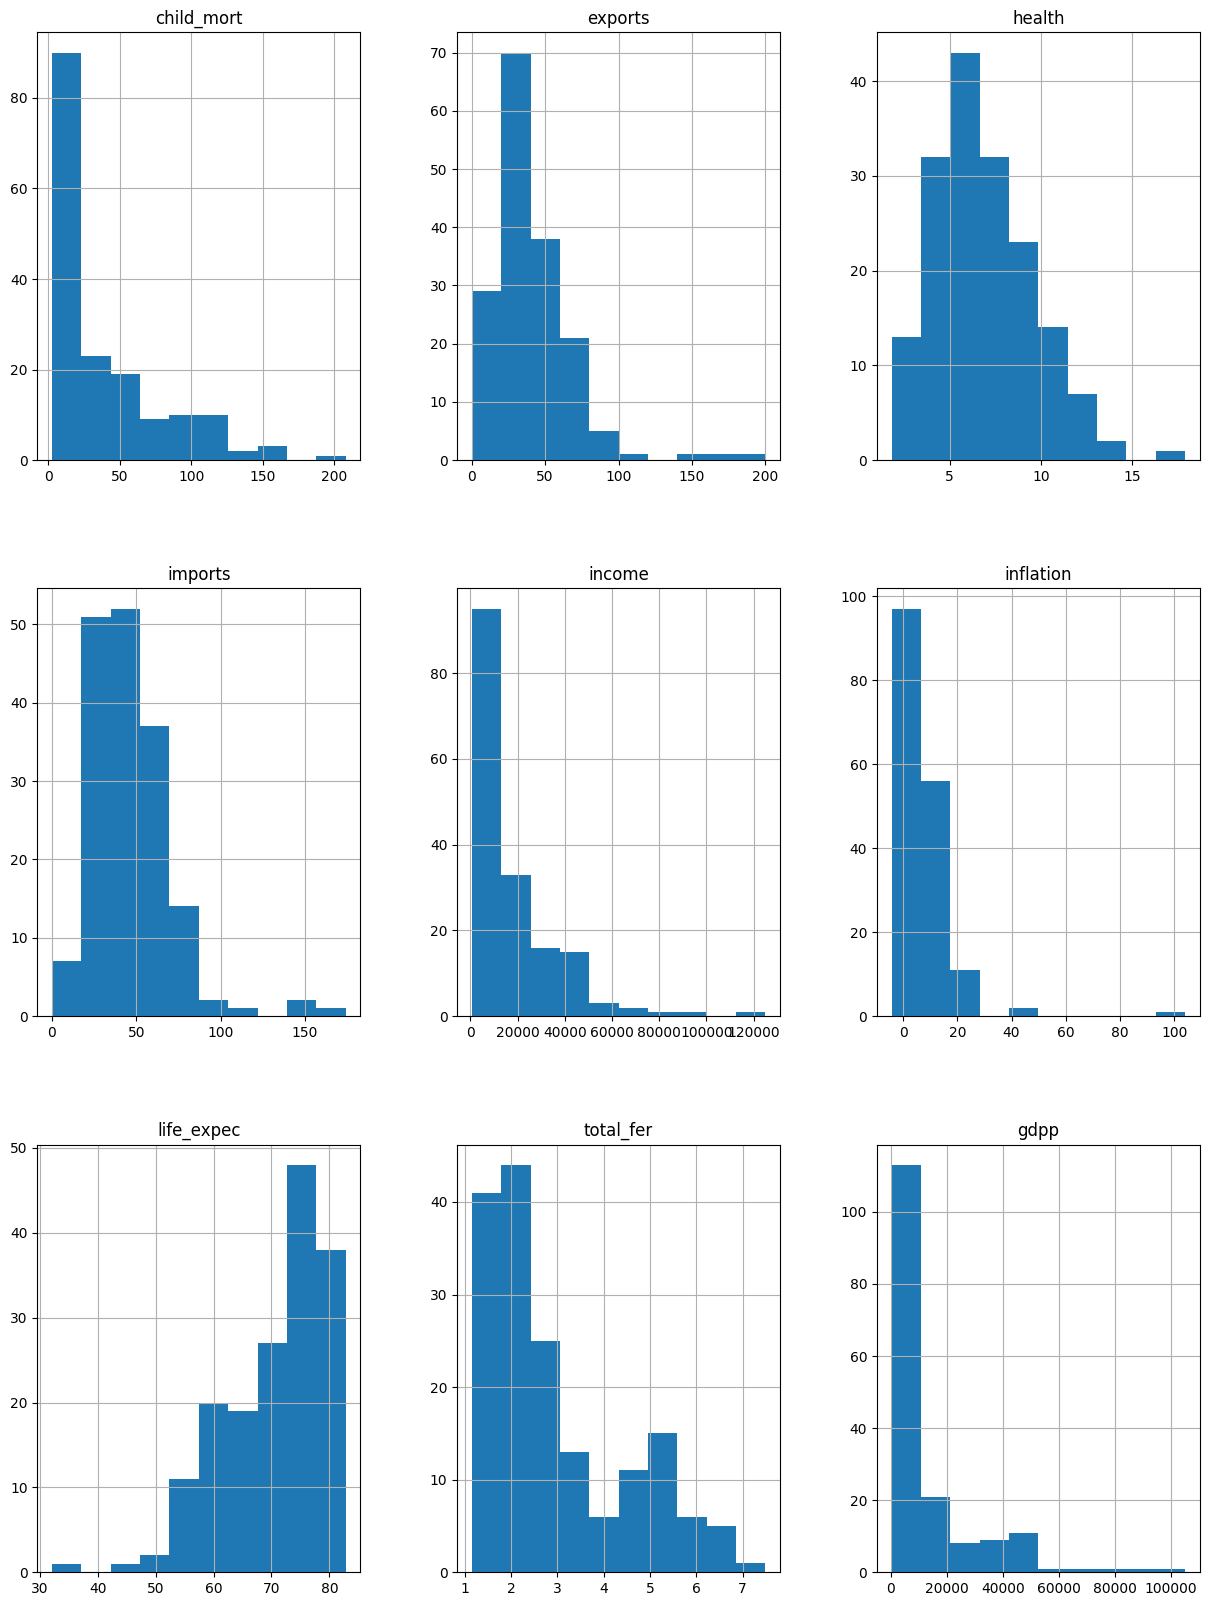

In [5]:
check_data(data)

<div class="alert-success"> 
<b> </b>
    
Сразу можно сказать, что данные выгружены корректно без потерь, пропусков и явных дубликатов в данных НЕ ОБНАРУЖЕНО, типы данных соответствуют содержимому признаков, названия столбцов датафрэйма корректны. Стоит отметить что уже на данном этапе, по построенным гистограммам видно, что выбросы в данных имеются) </div>

#### 1.2 Предобработка данных

<div class="alert-success"> 
<b> </b> Ну как было сказано ранее, в данных нет пропусков и янвных дубликатов, однако, проверить на НЕЯВНЫЕ дубликаты стоит столбец country). На этом предобработка данных будет завершена, с выбросами разберемся на следующем этапе) </div>

In [6]:
print(f"Вывод всех уникальных значений в столбце 'country': {data['country'].unique()}")

Вывод всех уникальных значений в столбце 'country': ['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cape Verde' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo, Dem. Rep.' 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cyprus' 'Czech Republic' 'Denmark' 'Dominican Republic'
 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana'
 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel'
 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan' 'Kenya' 'Kiribati'
 'Kuwait' 'Kyrgyz Repub

<div class="alert-success"> 
<b> </b> Неявных дубликатов в признаке нет, название каждой из стран отображаются корректно) </div>

#### 1.3 Анализ данных (EDA)

<div class="alert-success"> 
<b> </b>
Посмотрим как распределены признаки в датасете, постром гистограммы и ящик с усами)

Однако на данном этапе, я считаю, исходя из нашей задачи, что будет нецелесообразно удалять выбросы и "чистить данные", так как в нашем случае выбросами будут являтся либо самыми "нищими" (как раз таки кому и надо помочь, а мы их возьмем и удалим и никакой помощи они так и не получат) либо наоборот лидерами в благополучии и тд. а это тоже немаловажно. ПОЭТОМУ ИМЕННО В ЭТОЙ ЗАДАЧЕ ВЫБРОСЫ НЕ ТРОГАЕМ, ПРОСТОСЧИТАЕМ ИХ ПРОЦЕНТ В ПРИЗНАКЕ
</div>

In [7]:
def hist(column):
    print(data[column].describe())
    plt.hist(data[column])
    plt.title(f'Гистограмма распределения признака {column}')
    plt.xlabel(column)
    plt.ylabel("Количество клиентов")
    plt.show()
def bxplt(column):
    sns.boxplot(data=data, y=column)
    plt.title("Диаграмма размаха")
    plt.ylabel(column)
# def pie(column):
#     counts = data[column].value_counts()
#     print(counts)
#     fig, ax = plt.subplots()
#     ax.pie(counts, labels=counts.index, autopct='%.2f%%')
#     plt.title(f"Распределение признака {column}")
#     plt.show()

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


count    167.000000
mean      38.270060
std       40.328931
min        2.600000
25%        8.250000
50%       19.300000
75%       62.100000
max      208.000000
Name: child_mort, dtype: float64


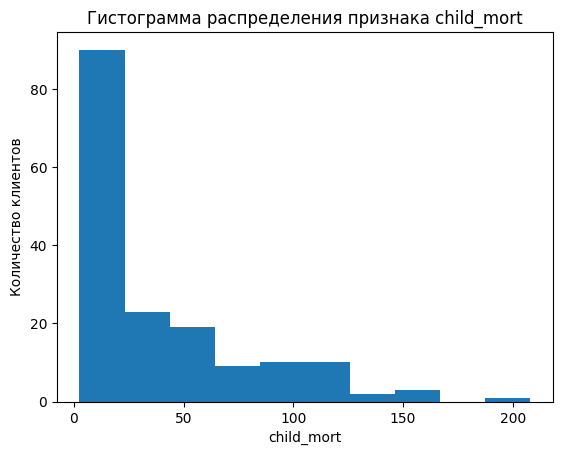

In [9]:
hist('child_mort')

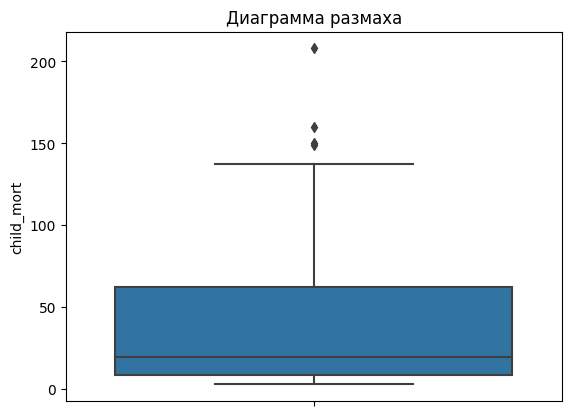

In [10]:
bxplt('child_mort')

In [11]:
print(f'Процент выбросов в признаке "child_mort": {(len(data.query("child_mort > 120")) / len(data) * 100)}%')

Процент выбросов в признаке "child_mort": 4.191616766467066%


In [12]:
# data = data.query('child_mort <= 120')

count    167.000000
mean      41.108976
std       27.412010
min        0.109000
25%       23.800000
50%       35.000000
75%       51.350000
max      200.000000
Name: exports, dtype: float64


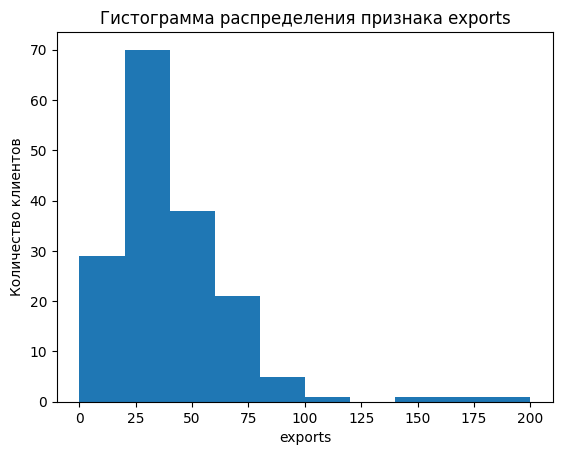

In [13]:
hist('exports')

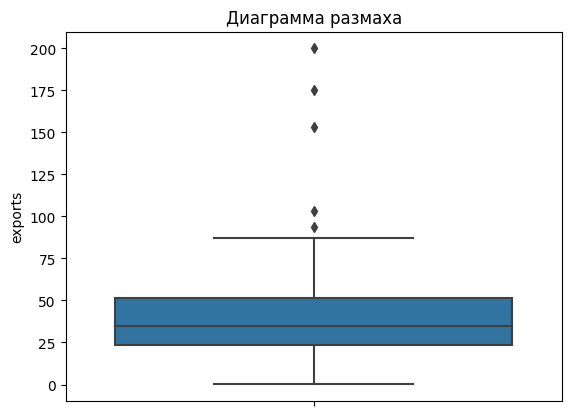

In [14]:
bxplt('exports')

In [15]:
print(f'Процент выбросов в признаке "exports": {(len(data.query("exports > 90")) / len(data) * 100)}%')

Процент выбросов в признаке "exports": 2.9940119760479043%


In [16]:
# data = data.query('exports <= 90')

count    167.000000
mean       6.815689
std        2.746837
min        1.810000
25%        4.920000
50%        6.320000
75%        8.600000
max       17.900000
Name: health, dtype: float64


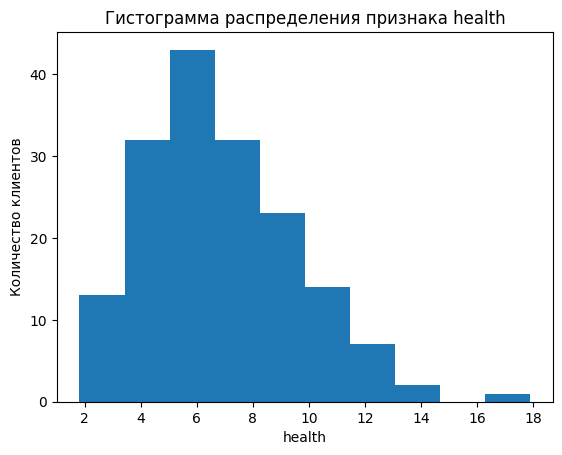

In [17]:
hist('health')

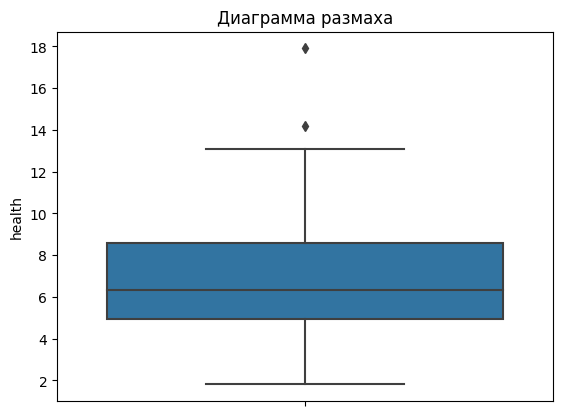

In [18]:
bxplt('health')

In [19]:
print(f'Процент выбросов в признаке "health": {(len(data.query("health > 12")) / len(data) * 100)}%')

Процент выбросов в признаке "health": 1.7964071856287425%


In [20]:
# data = data.query('health <= 12')

count    167.000000
mean      46.890215
std       24.209589
min        0.065900
25%       30.200000
50%       43.300000
75%       58.750000
max      174.000000
Name: imports, dtype: float64


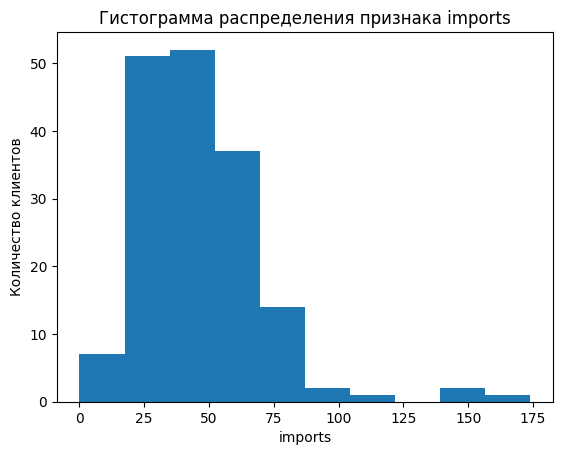

In [21]:
hist('imports')

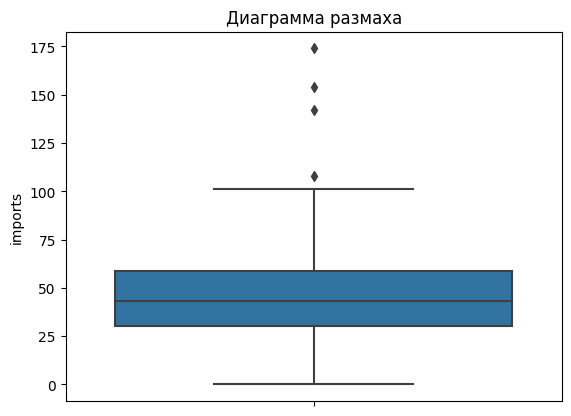

In [22]:
bxplt('imports')

In [23]:
print(f'Процент выбросов в признаке "imports": {(len(data.query("imports > 85")) / len(data) * 100)}%')

Процент выбросов в признаке "imports": 4.191616766467066%


In [24]:
# data = data.query('imports <= 85')

count       167.000000
mean      17144.688623
std       19278.067698
min         609.000000
25%        3355.000000
50%        9960.000000
75%       22800.000000
max      125000.000000
Name: income, dtype: float64


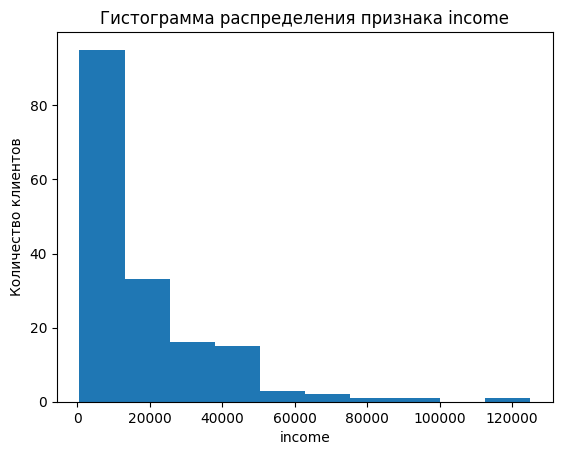

In [25]:
hist('income')

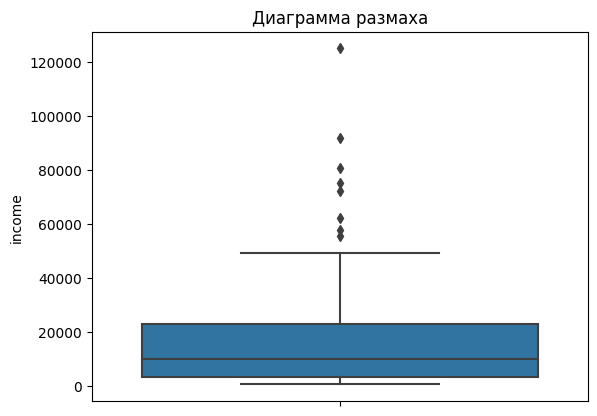

In [26]:
bxplt('income')

In [27]:
print(f'Процент выбросов в признаке "income": {(len(data.query("income > 46000")) / len(data) * 100)}%')

Процент выбросов в признаке "income": 5.389221556886228%


In [28]:
# data = data.query('income <= 46000')

count    167.000000
mean       7.781832
std       10.570704
min       -4.210000
25%        1.810000
50%        5.390000
75%       10.750000
max      104.000000
Name: inflation, dtype: float64


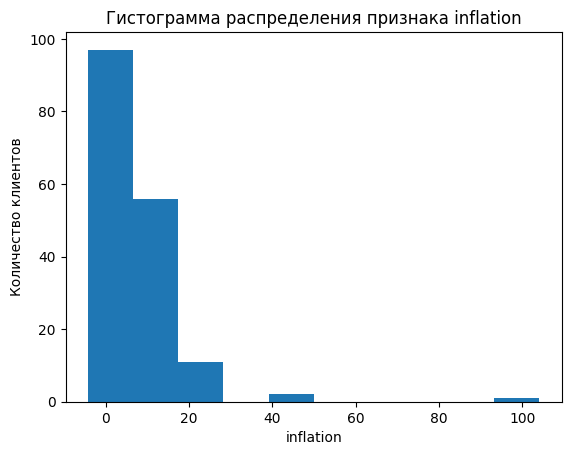

In [29]:
hist('inflation')

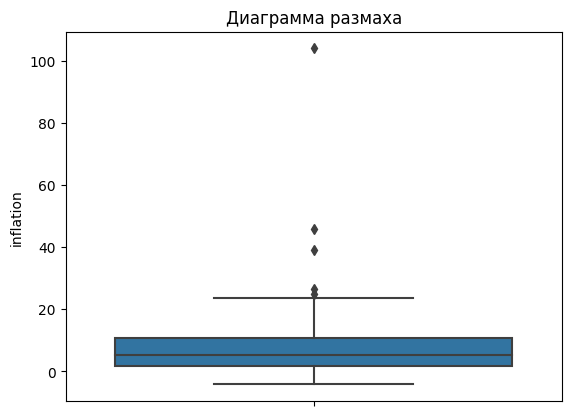

In [30]:
bxplt('inflation')

In [31]:
print(f'Процент выбросов в признаке "inflation": {(len(data.query("inflation > 24")) / len(data) * 100)}%')

Процент выбросов в признаке "inflation": 2.9940119760479043%


In [32]:
# data = data.query('inflation <= 24')

count    167.000000
mean      70.555689
std        8.893172
min       32.100000
25%       65.300000
50%       73.100000
75%       76.800000
max       82.800000
Name: life_expec, dtype: float64


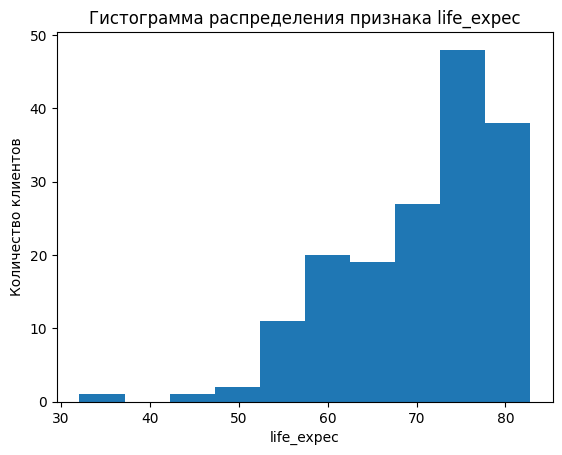

In [33]:
hist('life_expec')

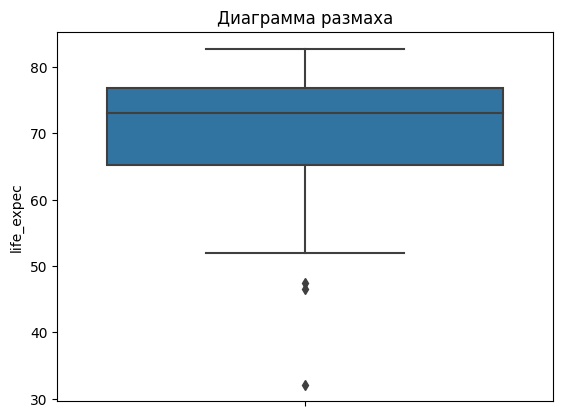

In [34]:
bxplt('life_expec')

count    167.000000
mean       2.947964
std        1.513848
min        1.150000
25%        1.795000
50%        2.410000
75%        3.880000
max        7.490000
Name: total_fer, dtype: float64


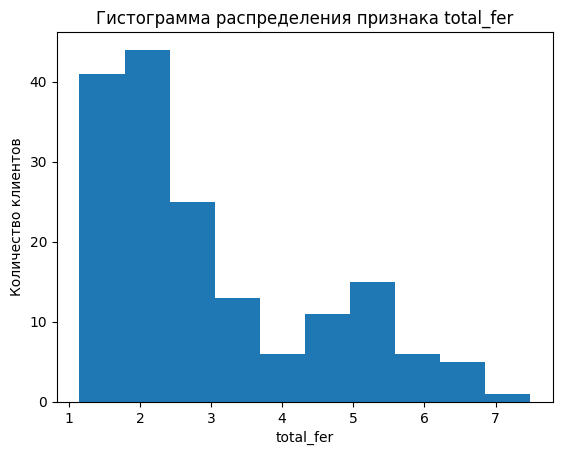

In [35]:
hist('total_fer')

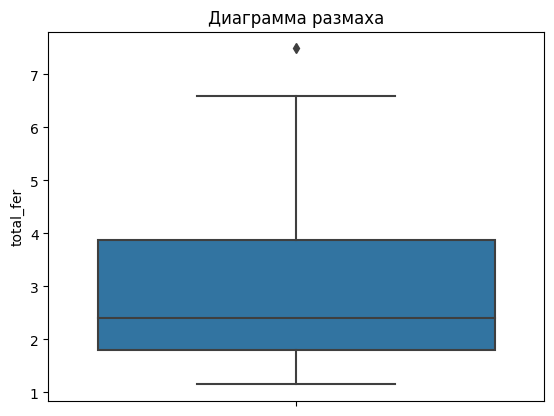

In [36]:
bxplt('total_fer')

In [37]:
# data = data.query('total_fer <= 6')

count       167.000000
mean      12964.155689
std       18328.704809
min         231.000000
25%        1330.000000
50%        4660.000000
75%       14050.000000
max      105000.000000
Name: gdpp, dtype: float64


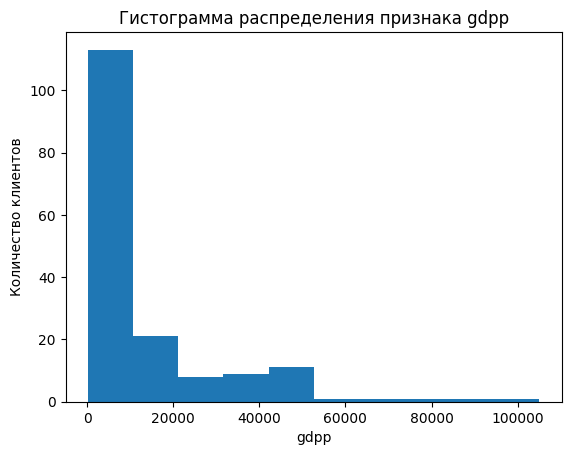

In [38]:
hist('gdpp')

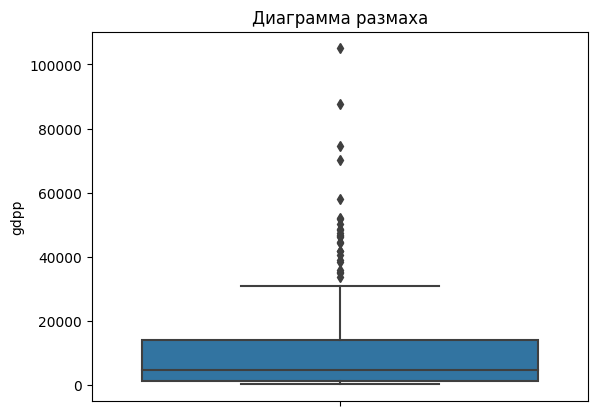

In [39]:
bxplt('gdpp')

In [40]:
print(f'Процент выбросов в признаке "gdpp": {(len(data.query("gdpp > 27000")) / len(data) * 100)}%')

Процент выбросов в признаке "gdpp": 17.365269461077844%


<div class="alert-success"> 
<b> </b>
Хочется отметить, что везде, кроме признака "gdpp", проценты выбросов незначительны, поэтому их удаление ничего бы сильно не поменяло бы, но вот страны-кандитаки на помощь могли бы быть утеряны(
</div>

<div class="alert-success"> 
<b> </b>
Теперь посмотрим, как будут корреллировать м/у собой признаки и также проверим на мультиколлениарность.
Здесь будет применена phik для анализа и нелинейных зависимостей.

Признак "country" будем считать как уникальный идентификатор

</div>

In [41]:
# data.columns

In [42]:
# создаём список с наименованиями непрерывных признаков
interval_cols = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

# считаем корреляции на выборке
phik_overview = phik_matrix(data.drop(['country'], axis=1), interval_cols=interval_cols)
print(phik_overview.shape)

(9, 9)


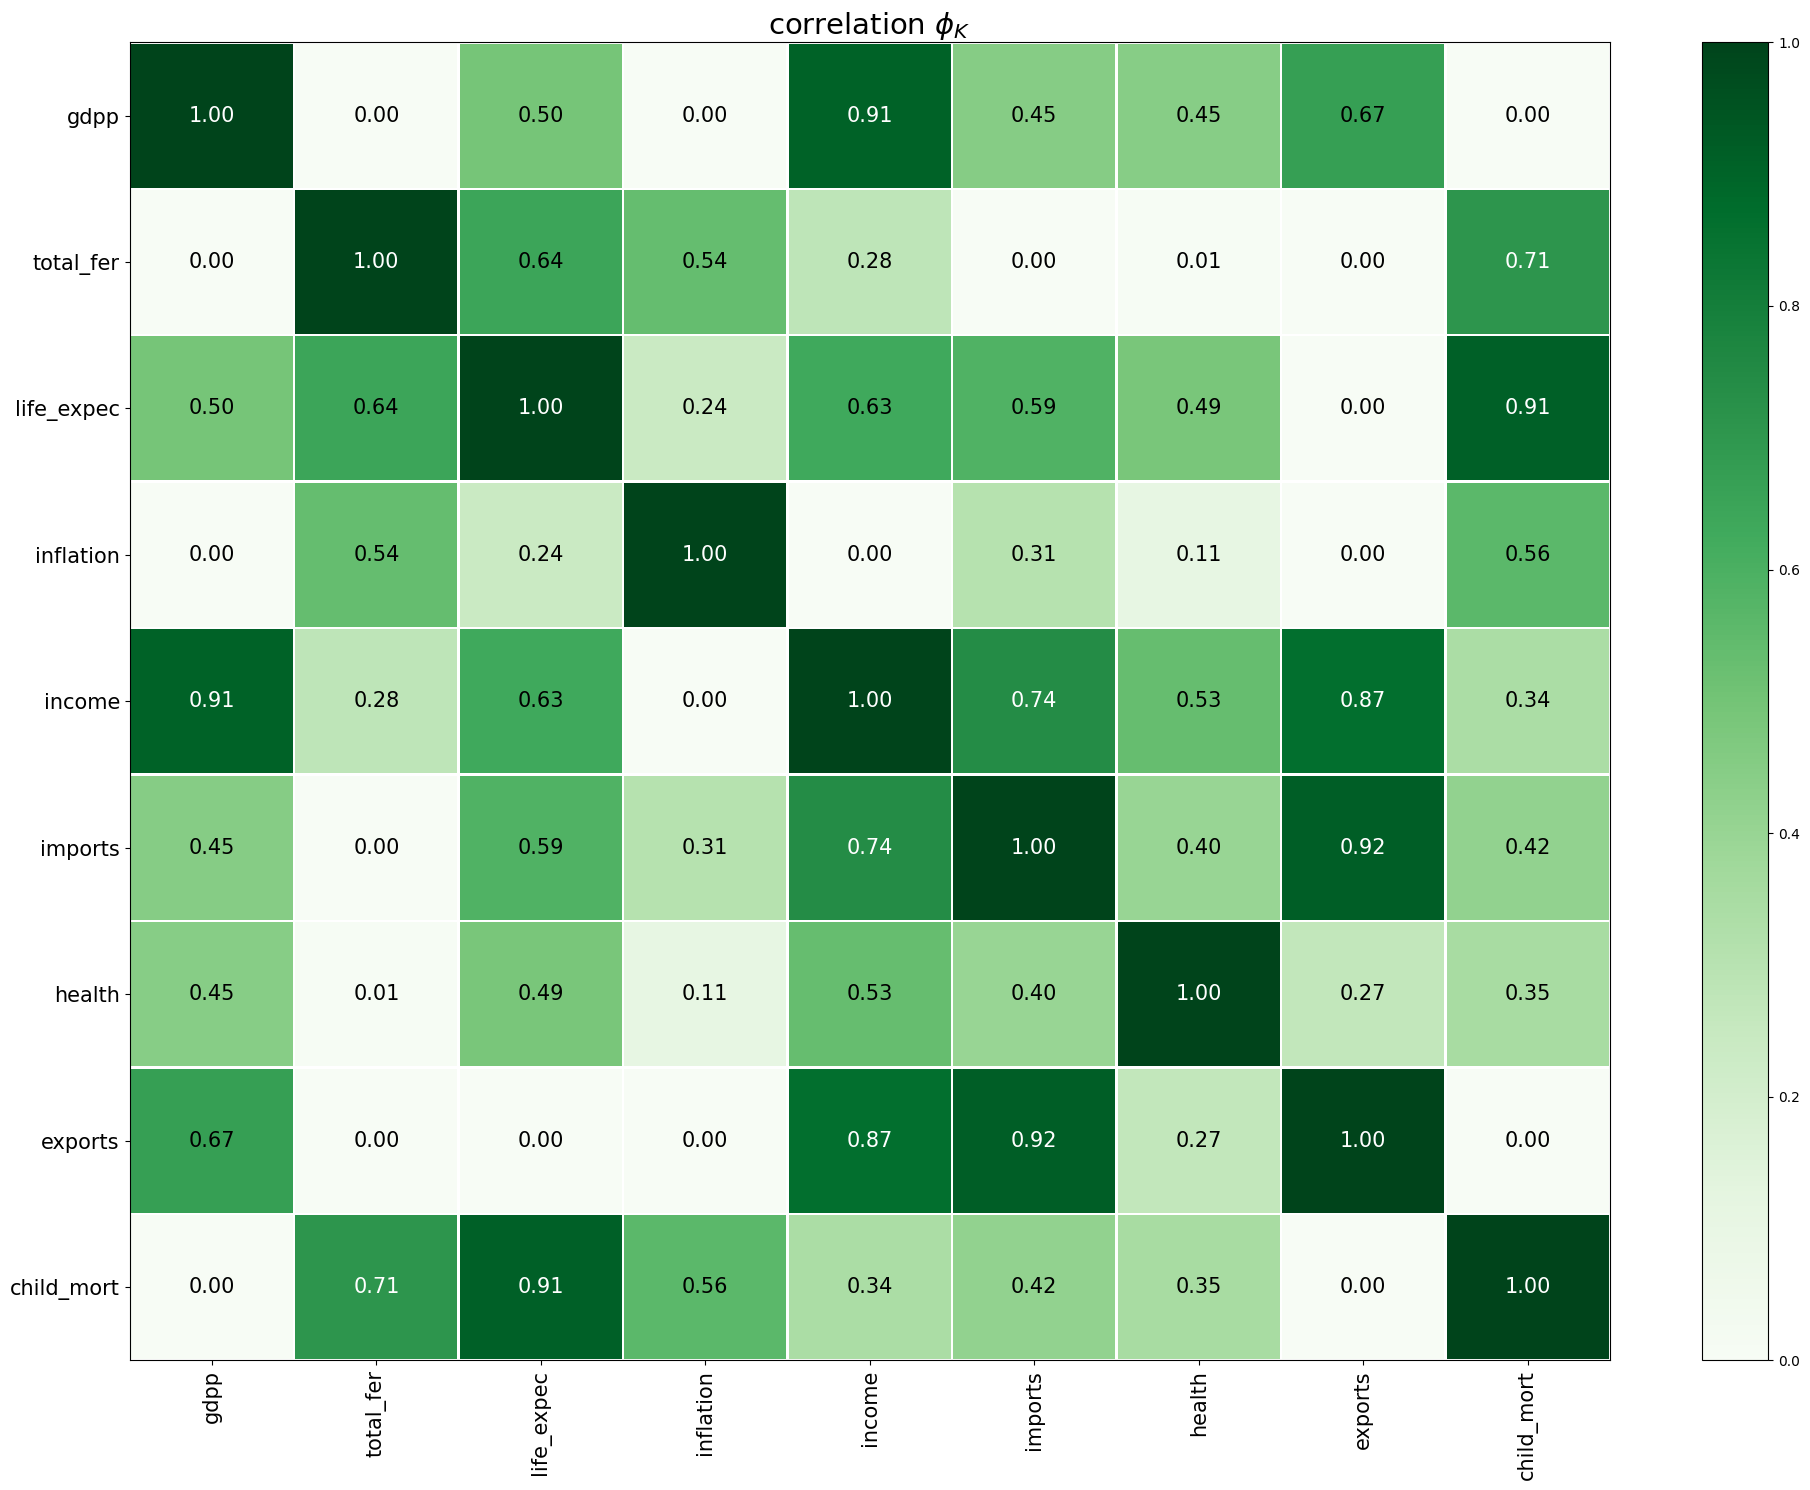

In [43]:
# Функции передаём значения матрицы корреляции phik_overview.values.
# Указываем наименования столбцов x_labels=phik_overview.columns.
# Указываем наименования строк y_labels=phi k_overview.index.
# Указываем цвет градиентной отрисовки vmin=0, vmax=1, color_map='Greens'.
# Добавляем заголовок title=r'correlation $\phi_K$'.
# Увеличиваем размер шрифта fontsize_factor=1.5.
# Увеличиваем размер графика figsize=(20, 15).

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

<div class="alert-success"> 
<b> </b>
Для нашей задачи, в частности кластеризации, мультиколлениарность между двумя признаками не столь критична, однако эти два признака несут в себе одинаковую информацию о состоянии здоровья/медицины страны и признак "life_expec - ожидаемая продолжительность жизни" менее информативен, так как это всего навсего теоретические рассчеты, а вот признак "child_mort - cмертность детей в возрасте до 5 лет на 1000 живорождений" напрямую связан с нуждаемостью страны в помощи.

Поэтому я думаю, что можно удалить признак life_expec. Можно конечно было бы применить метод PCA для устранения данной проблемы, но я не хочу этого делать)

</div>

In [44]:
data = data.drop(['life_expec'], axis=1).reset_index(drop=True)

#### 1.4 Кодирование данные

<div class="alert-success"> 
<b> </b>
Для начала уточним)
    
- Объект кластеризации — страна
- Признаки кластеризации — социально-экономические показатели (child_mort, exports, health, Imports, Income, Inflation, life_expec, total_fer, gdpp)

</div>

<div class="alert-success"> 
<b> </b>
Тут думать нечего, все признаки - числовые (кроме названия страны, его не трогаем), поэтому применяем сиандартизацию (StandardScaler) для K-means и Иерархическая кластеризация, а для DBSCAN нормализацию (MinMaxScaler)


</div>

In [45]:
country_names = data['country']

In [46]:
X = data.drop(['country'], axis=1)

<div class="alert-success"> 
<b> </b>
Стандартизируем для K-means и Иерархическая кластеризация
</div>

In [47]:
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)

<div class="alert-success"> 
<b> </b>
Нормализуем для DBSCAN
</div>

In [48]:
normalizer = MinMaxScaler()
X_normalized = normalizer.fit_transform(X)

### Шаг 2. Решение задачи кластеризации и определение оптимального количество кластеров для каждого из методов: 

#### 2.1 K-means

<div class="alert-success"> 
<b> </b>
Теперь, когда данные кодированны, применим алгоритм k-средних для их кластеризации. Для того чтобы определить оптимальное количество кластеров для наших данных, буду использовать метод локтя. Далее будет строитсяь график зависимости суммы внутрикластерных расстояний от числа кластеров и искать точку, где этот график начинает «выпрямляться».
</div>

In [49]:
inertia = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    kmeans.fit(X_scaler)
    inertia.append(kmeans.inertia_)

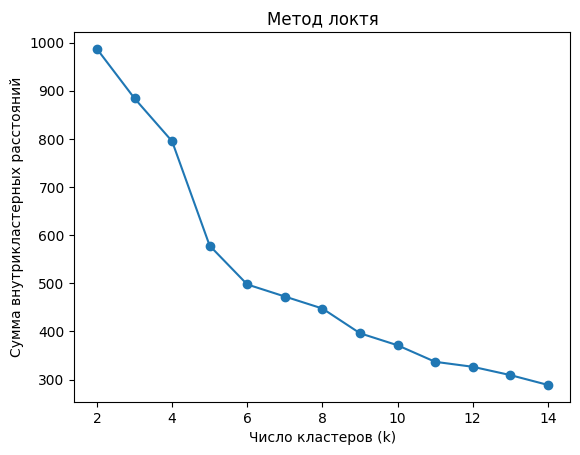

In [50]:
plt.plot(range(2, 15), inertia, marker='o')
plt.title("Метод локтя")
plt.xlabel("Число кластеров (k)")
plt.ylabel("Сумма внутрикластерных расстояний")
plt.show()

<div class="alert-success"> 
<b> </b>
На графике мы должны увидеть точку «локтя», где добавление новых кластеров перестает значительно уменьшать внутрикластерное расстояние.

Для нас точка локтя - будет наилучшее количество кластеров для наших данных. На данном графике видно, что инерция начинает уменьшаться значительно медленнее после k = 6, то это значит, что оптимальное число кластеров для вашего набора данных — ШЕСТЬ.
</div>

In [51]:
kmeans = KMeans(n_clusters=6, random_state=RANDOM_STATE)
kmeans.fit(X_scaler)

KMeans(n_clusters=6, random_state=42)

In [52]:
labels_kmeans = kmeans.labels_ 
centroids_kmeans = kmeans.cluster_centers_ 

#### 2.2 Иерархическая кластеризация

<div class="alert-success"> 
<b> </b>
Реализацию и интерпретацию иерархической кластеризации я взяла из статьи на Хабре https://habr.com/ru/companies/otus/articles/782862/
</div>

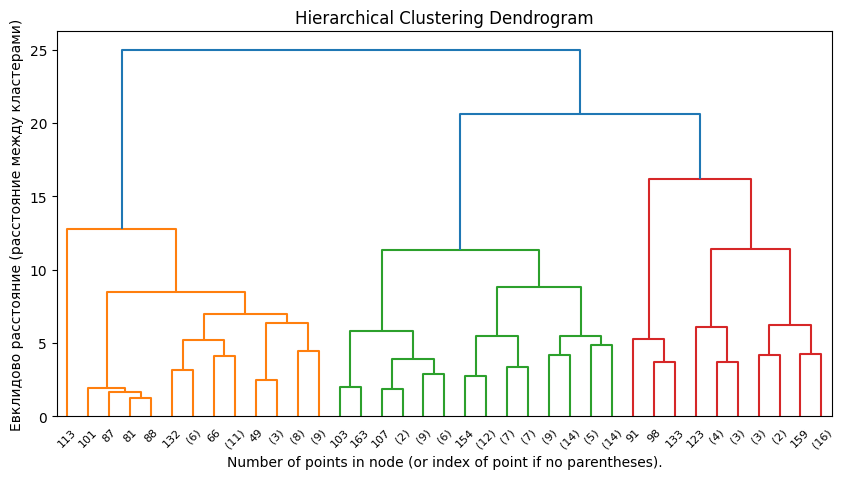

In [53]:
def plot_dendrogram(model, **kwargs):
  # Create linkage matrix and then plot the dendrogram
  # create the counts of samples under each node
  counts = np.zeros(model.children_.shape[0])
  n_samples = len(model.labels_)
  for (i, merge) in enumerate(model.children_):
    current_count = 0
    for child_idx in merge:
      if child_idx < n_samples:
        current_count += 1  # leaf node
      else:
        current_count += counts[child_idx - n_samples]
    counts[i] = current_count
  linkage_matrix = np.column_stack([model.children_,
      model.distances_, counts]).astype(float)
  # Plot the corresponding dendrogram
  dendrogram(linkage_matrix, **kwargs)

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

fitted = model.fit(X_scaler)

plt.figure(figsize=(10, 5))
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(fitted, truncate_mode="level", p=5)
plt.xlabel("Number of points in node (or index of point if no parentheses).")
plt.ylabel("Евклидово расстояние (расстояние между кластерами)")
plt.show()

<div class="alert-success"> 
<b> </b>
Итак, на дендрограмме видно, до высоты примерно 15 ветви сливаются часто и близко. А потом вдруг появляется "скачок" - слияние на большой высоте. Далее, если мы проведем горизонтальную линию на пороге 15, то количество пересеченных вертикальных линий будет равно 4. Т.е количество кластеров будет равно 4.

</div>

In [54]:
agg_clust = AgglomerativeClustering(n_clusters=4).fit(X_scaler)

In [55]:
labels_agg_clust = agg_clust.labels_ 

#### 2.3 DBSCAN

<div class="alert-success"> 
<b> </b>
у DBSCAN два ключевых параметра:
    
- eps — радиус окрестности точки
- min_samples — минимальное количество точек для образования кластера.

</div>

In [56]:
min_samples = 10 # потому что количесвто наших признаков 9 (не счтаем life_expec) плюсик 1

In [57]:
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_normalized)
distances, indices = neighbors_fit.kneighbors(X_normalized)

In [58]:
k_distances = np.sort(distances[:, -1])

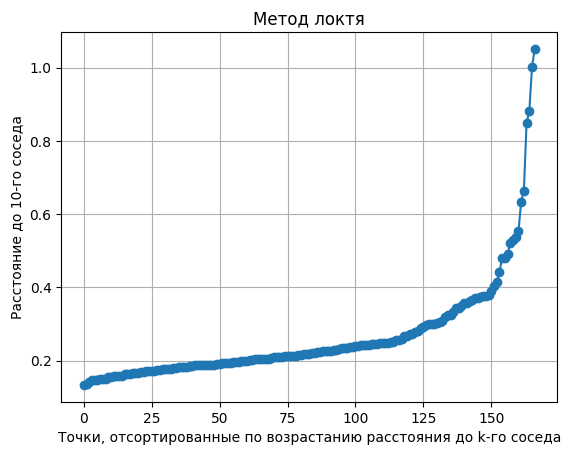

In [59]:
plt.plot(k_distances, marker='o')
plt.xlabel("Точки, отсортированные по возрастанию расстояния до k-го соседа")
plt.ylabel(f"Расстояние до 10-го соседа")
plt.title("Метод локтя")
plt.grid(True)
plt.show()

<div class="alert-success"> 
<b> </b>
Видно, что оптимальный eps соответсвует отметки примерно 0.2)))

</div>

In [60]:
eps_optimal = 0.205

In [61]:
dbscan = DBSCAN(eps=eps_optimal, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_normalized)

<div class="alert-success"> 
<b> </b>
На данном этапе мы получили три готовых алгоритма кластеризации обученных на наших данных и для каждого из них подобрали оптимальное количество кластеров.

Итак, количество кластеров для алгоритма K-means мы определили по графику "Локтя" и оно равняется - 6.
Далее с помощью дендрограммы мы определили оптимальное количество кластеров и для алгоритма иерархической кластеризации - 4.
И последнее, для DBSCAN не было нужды определять количество кластеров, однако нужно было разобраться с параметрами  "радиус окрестности точки" и "минимальное количество точек для образования кластера" - с помощью алгоритма NearestNeighbors и метода "Локтя" - 0.39 и 10 соотвественно)

Также на данном этапе были получены массивы с метками, который показывает, к какому кластеру принадлежит каждая страна после применения алгоритма кластеризации.

</div>

### Шаг 3. Основные выводы, ответ на вопрос - "Каким странам нужно помогать в первую очередь?". Описание выделенных кластеров. Описание эталонной страны в каждом кластере

#### 3.1 Анализ кластеров KMeans

<div class="alert-success"> 
<b> </b>
Начнем с кластеров полученными алгоритмом KMeans
</div>

In [62]:
data['clusters_kmeans'] = labels_kmeans

<div class="alert-success"> 
<b> </b>
Нам, чтобы определить, какой кластер стран будет самым нуждающимся, для начала нужно определить среднии значения признаков каждого из кластеров.
</div>

In [63]:
cluster_group = data.groupby('clusters_kmeans').mean(numeric_only=True)
print(cluster_group)

                 child_mort     exports    health     imports        income  \
clusters_kmeans                                                               
0                 31.072093   30.571605  5.258605   31.231765  12450.930233   
1                  5.100000   44.848148  9.361111   37.981481  46833.333333   
2                  4.133333  176.000000  6.793333  156.666667  64033.333333   
3                130.000000   25.300000  5.070000   17.400000   5150.000000   
4                 99.456757   27.968108  6.208919   41.240541   2939.810811   
5                 19.553571   49.135714  7.217321   61.587500  13522.321429   

                  inflation  total_fer          gdpp  
clusters_kmeans                                       
0                 11.935721   2.627209   5971.116279  
1                  2.891963   1.838519  45322.222222  
2                  2.468000   1.380000  57566.666667  
3                104.000000   5.840000   2330.000000  
4                 10.335811   5.32243

<div class="alert-success"> 
<b> </b>
Для лучшего пониманию, напишеи функцию, которая поможет визуализировать среднии значения признаков по кластерам)
</div>

In [64]:
def viz(column):
    cluster_group[column].plot(kind='bar')
    plt.title('Сравнение кластеров')
    plt.xlabel('Номер кластера')
    plt.ylabel(column)
    plt.show()

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Начнем с признака child_mort</b>
</div>

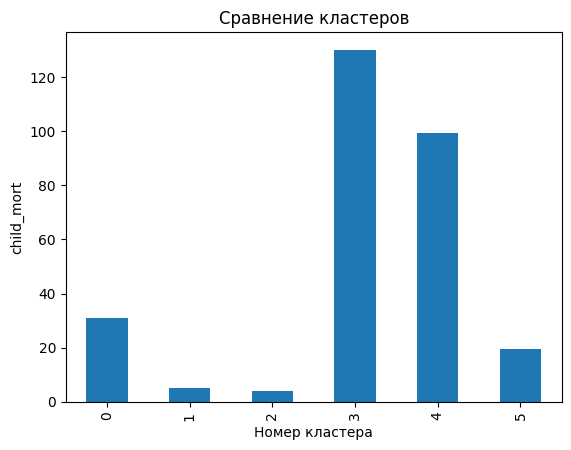

In [65]:
viz('child_mort')

<div class="alert-success"> 
<b> </b>
Видно, что наибольшая средняя детская смертность у стран в 3 и 4 кластерах, а вот в странах из 1, 2 кластеров - наименьшая
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак exports</b>
</div>

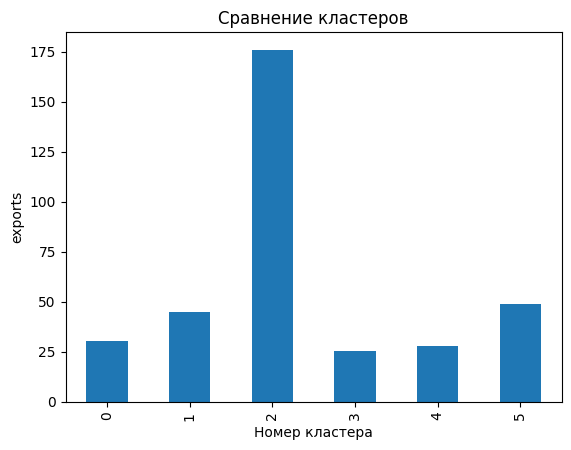

In [66]:
viz('exports')

<div class="alert-success"> 
<b> </b>
Лидирующими экспортерами являются страны из кластера 2, а лоутаб страны из кластеров 4 и 3
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак health</b>
</div>

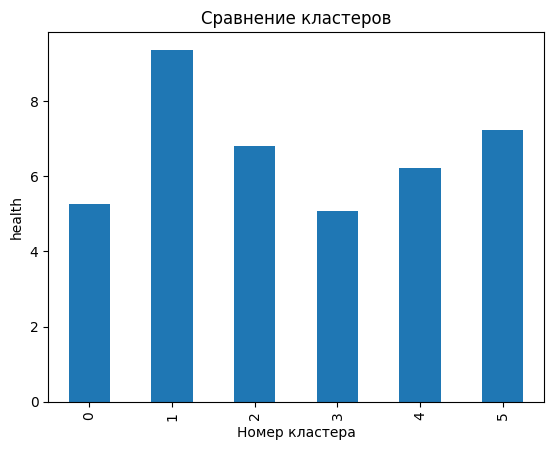

In [67]:
viz('health')

<div class="alert-success"> 
<b> </b>
Наибольшие общие расходы на здравохранения у стран из 1 кластера, меньше всего инвестиций в медицину  у стран из 3 кластера
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак imports</b>
</div>

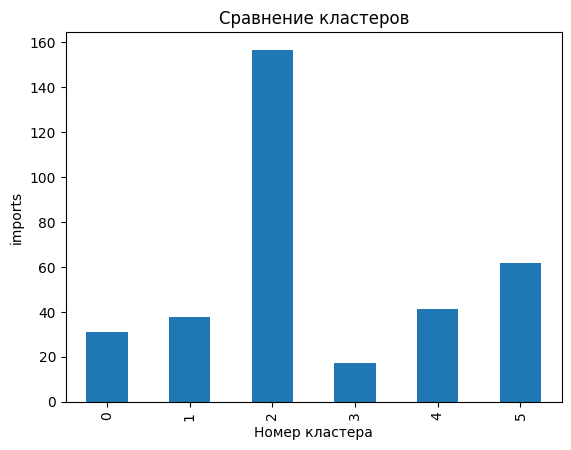

In [68]:
viz('imports')

<div class="alert-success"> 
<b> </b>
Страны - лидеры по импорту из 2 кластера. Аутсайдер - 3
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак income</b>
</div>

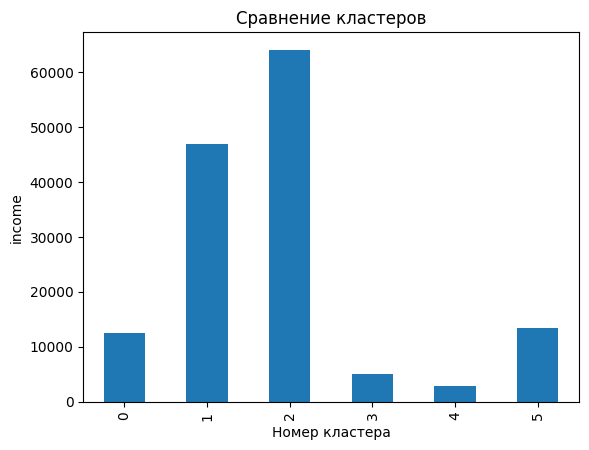

In [69]:
viz('income')

<div class="alert-success"> 
<b> </b>
Тут все понятно, наибольший чиситый доход на человека у стран из 1 и 2 классов, наименьший у 3 и 4
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак inflation</b>
</div>

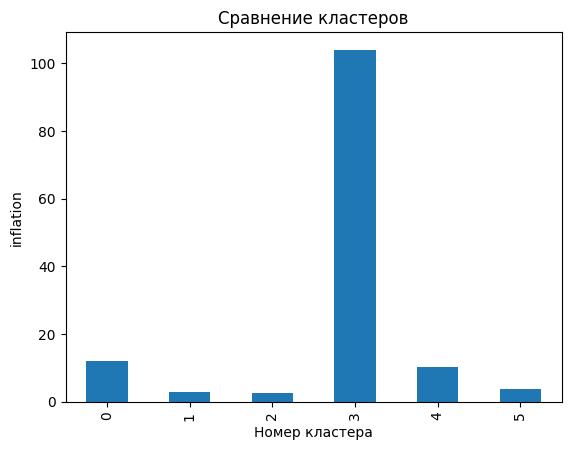

In [70]:
viz('inflation')

<div class="alert-success"> 
<b> </b>
Очень высокая инфляция у стран из 3 кластера, это значит, что у стран данного кластера очень нестабильная экономика. остальные более менее стабильны
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак total_fer</b>
</div>

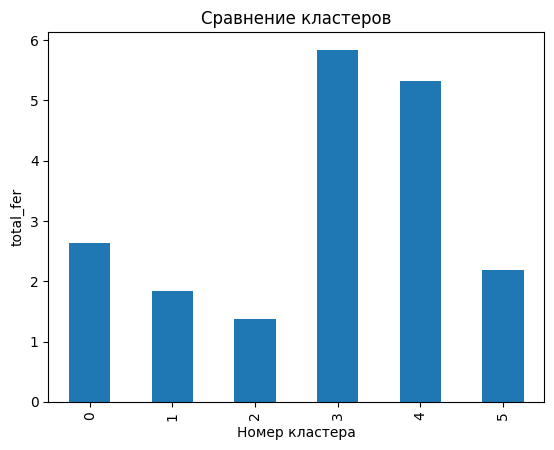

In [71]:
viz('total_fer')

<div class="alert-success"> 
<b> </b>
Наибольшая ожидаемая рождаемость у стран из 3 и 4 кластеров. Наименьшая - 2. Кстати обычно наибольшая рождаемость в бедных странах)))
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак gdpp</b>
</div>

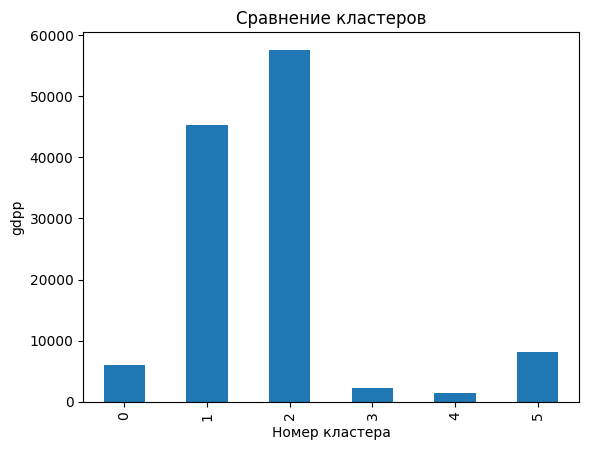

In [72]:
viz('gdpp')

<div class="alert-success"> 
<b> </b>
Самый низкий ВВП у стран из 3 и 4 кластера, наибольший из 1 и 2
</div>

<div class="alert-success"> 
<b> </b>
Мы рассмотрели все признаки, однако для определения стран для помощи далее мы будем опираться только на ЭТИ 5 ПРИЗНАКОВ: child_mort(должен быть высоким), income(должен быть низким), gdpp(должен быть низким), health(должен быть низким), 'inflation'(должна быть высокая)
</div>

In [73]:
sort_clusters = cluster_group.sort_values(by=['child_mort', 'income', 'gdpp', 'health', 'inflation'], ascending=[False, True, True, True, False])
print(sort_clusters[['child_mort', 'income', 'gdpp', 'health', 'inflation']].round(2))

                 child_mort    income      gdpp  health  inflation
clusters_kmeans                                                   
3                    130.00   5150.00   2330.00    5.07     104.00
4                     99.46   2939.81   1396.49    6.21      10.34
0                     31.07  12450.93   5971.12    5.26      11.94
5                     19.55  13522.32   8176.00    7.22       3.83
1                      5.10  46833.33  45322.22    9.36       2.89
2                      4.13  64033.33  57566.67    6.79       2.47


<div class="alert-success"> 
<b> </b>
Отлично, вырисовывается почти полная картина, видно что страны из кластеров 1, 5, 2, 0 точно не нуждаются в помощи. Страны из кластера 4 - прямые кандидаты в страны, которым нужно оказать помощь, однако, СТРАНЫ которым нужно оказывать помощь ЗДЕСЬ И СЕЙЧАС должны быть выбраны из кластера 3. У данного кластера наибольшая детская смертность и просто огромная по сравнению с другими инфляция которая вразы больше чем у других кластеров. Также у данного кластера один из самых низких ВВП и чистый доход на человека и самые низкий уровень инвестиций в здравоохранение.

Теперь выведем топ 6 стран из кластера которым нужно оказать помощь --->
</div>

In [74]:
cluster_3 = data[data['clusters_kmeans'] == 3]

In [75]:
cluster_3

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans
113,Nigeria,130.0,25.3,5.07,17.4,5150,104.0,5.84,2330,3


<div class="alert-success"> 
<b> </b>
Прикольно, в этом кластере оказывается только одна страна))) Ладно, тогда ее точно выбираем как нуждающуюся в помощи, а остальные страны доберем из 4 кластера)
</div>

In [76]:
cluster_4 = data[data['clusters_kmeans'] == 4]

In [77]:
cluster_4_sort = cluster_4.sort_values(by=['child_mort', 'income', 'gdpp', 'health', 'inflation'], ascending=[False, True, True, True, False])

In [78]:
top_4 = cluster_4_sort[['country', 'child_mort', 'income', 'gdpp', 'health', 'inflation']].head(5)
print(top_4)

                      country  child_mort  income  gdpp  health  inflation
66                      Haiti       208.0    1500   662    6.91       5.45
132              Sierra Leone       160.0    1220   399   13.10      17.20
32                       Chad       150.0    1930   897    4.53       6.39
31   Central African Republic       149.0     888   446    3.98       2.01
97                       Mali       137.0    1870   708    4.98       4.37


<div class="alert-success"> 
<b> </b>
Ну и отлично, вот топ ШЕСТЬ стран которые нуждаются в помощи исходя из анализа работы алгоритма KMeans

- 1)Haiti
- 2)Sierra Leone
- 3)Chad
- 4)Central African Republic
- 5)Mali
- 6)Nigeria
</div>

<div class="alert-success"> 
<b> </b>
Теперь найдем эталонную страну каждого из кластера) и после опишем каждый кластер)

Эталонную страну выбираем так - наименьшее расстояние до центроида кластера)
</div>

In [79]:
data['distance_to_centroid'] = np.nan

In [80]:
print('ЭТАЛОННАЯ СТРАНА ИЗ ...')
for i in range(kmeans.n_clusters):
    cluster_points = X_scaler[data['clusters_kmeans'] == i]
    centroid = centroids_kmeans[i]
    distances = cdist(cluster_points, [centroid]).flatten()
    data.loc[data['clusters_kmeans'] == i, 'distance_to_centroid'] = distances
    closest_idx = distances.argmin()
    country = data[data['clusters_kmeans'] == i].iloc[closest_idx]['country']
    print(f'Кластера {i}: {country}')

ЭТАЛОННАЯ СТРАНА ИЗ ...
Кластера 0: Egypt
Кластера 1: Sweden
Кластера 2: Singapore
Кластера 3: Nigeria
Кластера 4: Malawi
Кластера 5: Tunisia


In [81]:
data[data['country'] == 'Egypt']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid
47,Egypt,29.1,21.3,4.66,26.6,9860,10.1,3.19,2600,0,0.650907


In [82]:
data[data['country'] == 'Sweden']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid
144,Sweden,3.0,46.2,9.63,40.7,42900,0.991,1.98,52100,1,0.498267


In [83]:
data[data['country'] == 'Singapore']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,1.15,46600,2,1.724754


In [84]:
data[data['country'] == 'Nigeria']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid
113,Nigeria,130.0,25.3,5.07,17.4,5150,104.0,5.84,2330,3,0.0


In [85]:
data[data['country'] == 'Malawi']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid
94,Malawi,90.5,22.8,6.59,34.9,1030,12.1,5.31,459,4,0.462974


In [86]:
data[data['country'] == 'Tunisia']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid
152,Tunisia,17.4,50.5,6.21,55.3,10400,3.82,2.14,4140,5,0.53376


<div class="alert-success"> 
<b> </b>
Итак, давайте проанализируем каждый кластер с его эталонной страной)
</div>

<div class="alert-success"> 
<b> </b>
Кластер 0 - страны в данном кластере они не являются бедными, они слегка не дотягивают до середничков, чистый доход на человека у них намного выше чем в бедных странах, которые находятся на грани нищеты, и относительно им же у них низкая детская смертномть. Поэтому страны в этом кластере по оценкам по благополучию идут сразу после стран из кластеров 3 и 4(неблагополучных), однако с очень большим отрывом от них в лучшую сторону.

- Эталонная страна Египет (чуть выше среднего детская смертность, инфляция состовляет 10.1 процент, ВВП на душу населения - 2600, что относительно низкий показатель, а чистый доход на человека состовляет - 9860). но все таки Египет скорее можно назвать страной с низким уровнем дохода, чем богатой, поскольку значительная часть населения живет за чертой бедности, несмотря на то, что страна является одной из самых экономически развитых в Северной Африке.

Кластер 1 - второй по благополучию кластер, эти страны не бедствуют и с медециной и экономикой у них все отлично, конечно же никакая помощь им не нужно, скорее всего они сами могут предложить свою).

- Эталонная страна - Швеция - наивысший ВВП из всех эталонных стран - 52100. Швеция – богатая и развитая страна, которая стабильно занимает высокие позиции по уровню жизни, экономическому развитию и конкурентоспособности.

Кластер 2 - долго не буду говорить, самые благополучные богатые страны, с самой лучше медициной и экономикой.

- Эталонная страна - Сингапур - наивысшие экспорт и импорт, чистый доход и самая низкая детская смертность из всех эталонных стран и ОТРИЦАТЕЛЬНОЙ ИНФЛЯЦИЕЙ!!! Сингапур — очень богатая страна, занимающая одно из лидирующих мест в мире по ВВП на душу населения и уровню экономического развития. Это одна из самых развитых экономик мира, что подтверждается высоким уровнем жизни, развитой инфраструктурой, низким уровнем коррупции и сильной позицией в сфере высоких технологий. 

Кластер 3 - состоит из одной страны Нигерии - , она же является эталонной) - у которой самые высокие и инфляция и детская смертность и высокий уровень бедности: Значительная часть населения (около 63%) живет за чертой бедности. - ТРЕБУЕТСЯ ПОМОЩЬ

Кластер 4 - самые нищие и неблагополучные страны котрым нужна помощь, эталонная страна - Малави — бедная страна, одна из самых бедных в мире., самый маленький ВВП из всех эталонных стран) - ТРЕБУЕТСЯ ПОМОЩЬ

Кластер 5 - эталонные середнечки, ближе к благополучию, не нуждаются в помощи, эталонная страна - Tunisia, все у ней хорошо, низкая детская смертность, средний импорт и экспорт и тд. Тунис -  он классифицируется как развивающаяся страна с умеренным уровнем благосостояния по сравнению с другими африканскими странами.
</div>

#### 3.2 Анализ кластеров Иерархической кластеризации

<div class="alert-success"> 
<b> </b>
Все тоже самое, что и с KMeans, тобишь аналогично)
</div>

In [87]:
data['clusters_agg'] = labels_agg_clust

In [88]:
cluster_group = data.groupby('clusters_agg').mean(numeric_only=True)
print(cluster_group)

              child_mort     exports    health     imports        income  \
clusters_agg                                                               
0              91.660000   27.869333  6.657778   45.360000   3250.288889   
1               6.190000   47.543333  8.701000   38.660000  46543.333333   
2              23.239326   41.087404  6.260787   46.737819  12679.775281   
3               4.133333  176.000000  6.793333  156.666667  64033.333333   

              inflation  total_fer          gdpp  clusters_kmeans  \
clusters_agg                                                        
0             11.748778   5.088667   1596.844444         3.711111   
1              4.358433   1.901333  42150.000000         1.033333   
2              7.109146   2.271236   7370.292135         2.921348   
3              2.468000   1.380000  57566.666667         2.000000   

              distance_to_centroid  
clusters_agg                        
0                         1.676618  
1                

<div class="alert-success"> 
<b> </b>
В этот раз будем рассматривать поближе только средние значения у 5 самых важных признаков) - 'child_mort', 'income', 'gdpp', 'health', 'inflation'
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак child_mort</b>
</div>

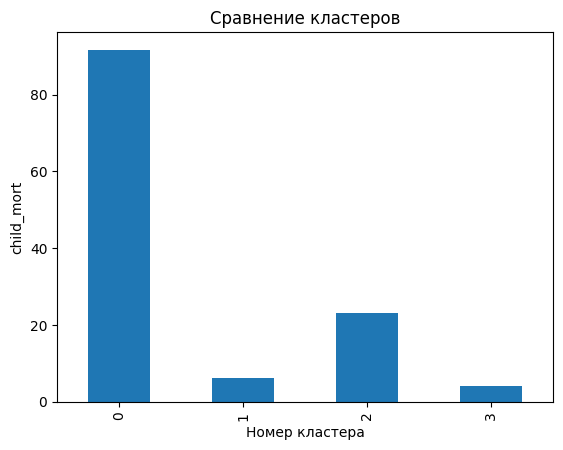

In [89]:
viz('child_mort')

<div class="alert-success"> 
<b> </b>
Очевидно, что кластер с самой высокой детской смертностью - 0, низкой - 1
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак income</b>
</div>

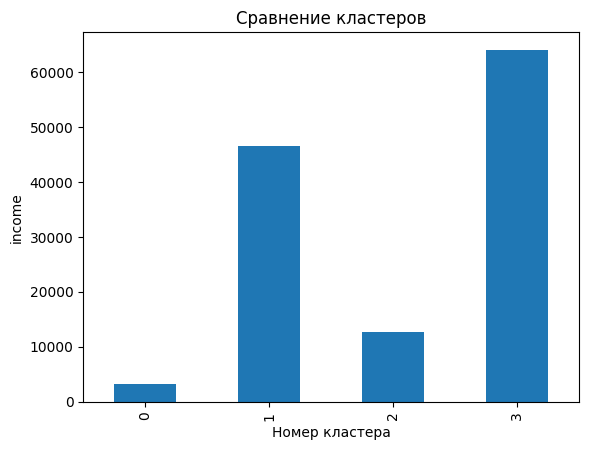

In [90]:
viz('income')

<div class="alert-success"> 
<b> </b>
Кластер с самым высоким чистым доходом на человека - 3, низким - 0
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак health</b>
</div>

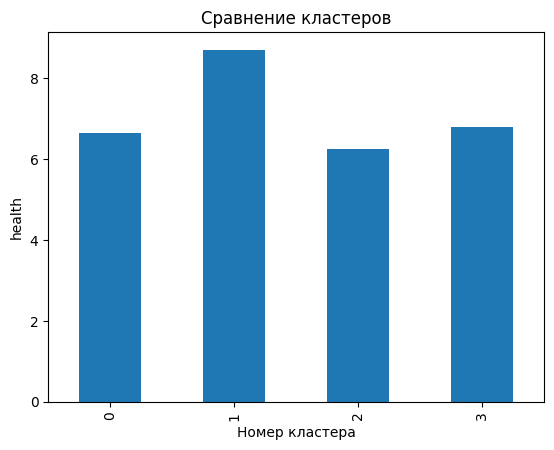

In [91]:
viz('health')

<div class="alert-success"> 
<b> </b>
Кластер с самыми высокими общими расходами на здравоохранение на душу населения - 1, наименьший - 2 и 0
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак gdpp</b>
</div>

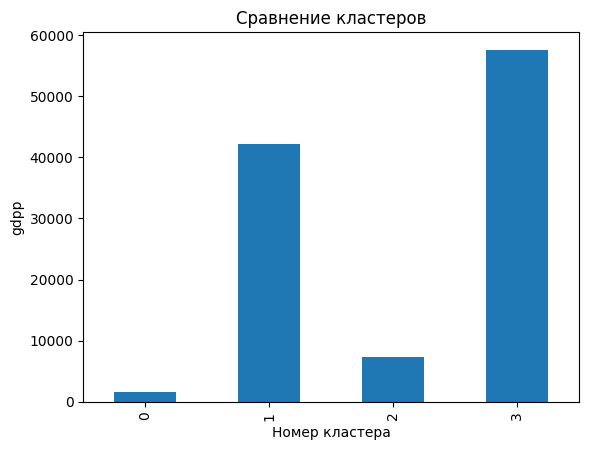

In [92]:
viz('gdpp')

<div class="alert-success"> 
<b> </b>
ВВП на душу населения у стран кластера 3 наибольший, 0 - наименьший
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак inflation</b>
</div>

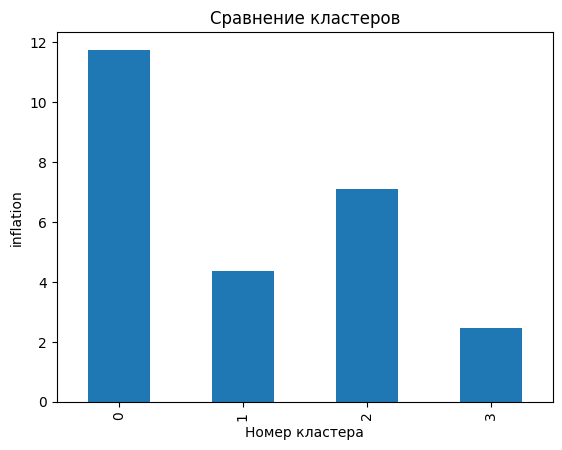

In [93]:
viz('inflation')

<div class="alert-success"> 
<b> </b>
Ну и конечно же, самая высокая инфляция у стран кластера 0, и низкая у кластера 3
</div>

<div class="alert-success"> 
<b> </b>
Уже на данном этапе понятно, что страны из кластера 3 не будут нуждаться в помощи, а из кластера 0 - будут
</div>

In [94]:
sort_clusters = cluster_group.sort_values(by=['child_mort', 'income', 'gdpp', 'health', 'inflation'], ascending=[False, True, True, True, False])
print(sort_clusters[['child_mort', 'income', 'gdpp', 'health', 'inflation']].round(2))

              child_mort    income      gdpp  health  inflation
clusters_agg                                                   
0                  91.66   3250.29   1596.84    6.66      11.75
2                  23.24  12679.78   7370.29    6.26       7.11
1                   6.19  46543.33  42150.00    8.70       4.36
3                   4.13  64033.33  57566.67    6.79       2.47


<div class="alert-success"> 
<b> </b>
чтд...
</div>

In [95]:
cluster_0 = data[data['clusters_agg'] == 0]

In [96]:
# cluster_0

In [97]:
cluster_0_sort = cluster_0.sort_values(by=['child_mort', 'income', 'gdpp', 'health', 'inflation'], ascending=[False, True, True, True, False])

In [98]:
top_6 = cluster_0_sort[['country', 'child_mort', 'income', 'gdpp', 'health', 'inflation']].head(6)
print(top_6)

                      country  child_mort  income  gdpp  health  inflation
66                      Haiti       208.0    1500   662    6.91       5.45
132              Sierra Leone       160.0    1220   399   13.10      17.20
32                       Chad       150.0    1930   897    4.53       6.39
31   Central African Republic       149.0     888   446    3.98       2.01
97                       Mali       137.0    1870   708    4.98       4.37
113                   Nigeria       130.0    5150  2330    5.07     104.00


<div class="alert-success"> 
<b> </b>
Опа, где то я уже это видела)))

Топ 6 стран КОТОРЫМ НЕОБХОДИМО ОКАЗАТЬ ПОМОЩЬ исходя из работы алгоритма иерархической кластеризации --->

1) Haiti
2) Sierra Leone
3) Chad
4) Central African Republic
5) Mali
6) Nigeria

</div>

In [99]:
data['distance_to_centroid_agg'] = np.nan
X_scaled_df = pd.DataFrame(X_scaler, columns=X.columns)

<div class="alert-success"> 
<b> </b>
AgglomerativeClustering не хранит центроиды поэтому я просто заменю на centroid = cluster_points.mean().values.reshape(1, -1)
</div>

In [100]:
print('ЭТАЛОННАЯ СТРАНА ИЗ ИЕРАРХИЧЕСКИХ КЛАСТЕРОВ:')
for i in range(np.max(labels_agg_clust) + 1):
    cluster_points = X_scaled_df[data['clusters_agg'] == i]
    centroid = cluster_points.mean().values.reshape(1, -1)
    distances = cdist(cluster_points, centroid).flatten()
    data.loc[data['clusters_agg'] == i, 'distance_to_centroid_agg'] = distances
    closest_idx = distances.argmin()
    country = data[data['clusters_agg'] == i].iloc[closest_idx]['country']
    print(f'Иерархический кластер {i}: эталонная страна — {country}')

ЭТАЛОННАЯ СТРАНА ИЗ ИЕРАРХИЧЕСКИХ КЛАСТЕРОВ:
Иерархический кластер 0: эталонная страна — Malawi
Иерархический кластер 1: эталонная страна — Iceland
Иерархический кластер 2: эталонная страна — Suriname
Иерархический кластер 3: эталонная страна — Singapore


In [101]:
data[data['country'] == 'Malawi']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid,clusters_agg,distance_to_centroid_agg
94,Malawi,90.5,22.8,6.59,34.9,1030,12.1,5.31,459,4,0.462974,0,0.513311


In [102]:
data[data['country'] == 'Iceland']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid,clusters_agg,distance_to_centroid_agg
68,Iceland,2.6,53.4,9.4,43.3,38800,5.47,2.2,41900,1,0.691012,1,0.607267


In [103]:
data[data['country'] == 'Suriname']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid,clusters_agg,distance_to_centroid_agg
143,Suriname,24.1,52.5,7.01,38.4,14200,7.2,2.52,8300,5,1.052226,2,0.636469


In [104]:
data[data['country'] == 'Singapore']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid,clusters_agg,distance_to_centroid_agg
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,1.15,46600,2,1.724754,3,1.724754


<div class="alert-success"> 
<b> </b>
Итак, давайте проанализируем каждый кластер с его эталонной страной)
</div>

<div class="alert-success"> 
<b> </b>
Кластер 0 - страны в данном кластере являются бедными и НУЖДАЮТСЯ В ПОМОЩИ, у них наивысшая детская смертность и самая высокая инфляция, зато самый низкий ВВП и Чистый доход на человека

- Эталонная страна МАЛАВИ - является одной из самых бедных стран мира и одной из самых бедных в Африке. Экономика страны сильно зависит от сельского хозяйства, в котором занята большая часть населения, а ключевым экспортным товаром является табак. Высокий уровень бедности в Малави обусловлен такими факторами, как низкий ВВП на душу населения, зависимость от аграрного сектора, подверженного влиянию климатических изменений, ограниченная инфраструктура и высокий темп роста населения.


Кластер 1 - второй по благополучию кластер, эти страны не бедствуют и с медециной и экономикой у них все отлично, конечно же никакая помощь им не нужно, скорее всего они сами могут предложить свою).

- Эталонная страна - Исландия – богатая страна, хотя и с очень высокой стоимостью жизни. Экономика Исландии, построенная по скандинавской модели, отличается высоким уровнем жизни, низким уровнем безработицы и равномерным распределением доходов. У данной страны наименьшая детская смертность

Кластер 2 - страны котрые слегка ниже среднего, они не бедные, экономика и медицина у них не в упадке. Однако они находятся по показателям почти на гране)

- Эталонная страна - Суринам - можно охарактеризовать как страну выше среднего уровня дохода с богатыми природными ресурсами, но с высоким уровнем бедности и зависимой экономикой. 

Кластер 3 - долго не буду говорить, самые благополучные богатые страны, с самой лучше медициной и экономикой.

Эталонная страна - Сингапур - наивысшие экспорт и импорт, чистый доход и самая низкая детская смертность из всех эталонных стран и ОТРИЦАТЕЛЬНОЙ ИНФЛЯЦИЕЙ!!! Сингапур — очень богатая страна, занимающая одно из лидирующих мест в мире по ВВП на душу населения и уровню экономического развития. Это одна из самых развитых экономик мира, что подтверждается высоким уровнем жизни, развитой инфраструктурой, низким уровнем коррупции и сильной позицией в сфере высоких технологий.
</div>

#### 3.3 Анализ кластеров DBSCAN

<div class="alert-success"> 
<b> </b>
Аналогично...
</div>

In [105]:
data['cluster_dbscan'] = labels_dbscan

In [106]:
data['cluster_dbscan'].value_counts()

 0    81
-1    49
 1    21
 2    16
Name: cluster_dbscan, dtype: int64

<div class="alert-success"> 
<b> </b>
Видим, что алгоритм вынес как шум 49 стран, то есть кластер -1 является таким, что там находятся разные страны, разношерстоных видов)
</div>

In [107]:
cluster_group = data.groupby('cluster_dbscan').mean(numeric_only=True)
print(cluster_group)

                child_mort    exports     health    imports        income  \
cluster_dbscan                                                              
-1               54.034694  51.649367   6.970204  54.464610  24489.693878   
 0               21.850617  40.191111   6.379012  47.295062  12602.962963   
 1               90.833333  25.933333   5.546190  38.409524   2158.476190   
 2                4.125000  33.393750  10.219375  32.775000  37312.500000   

                inflation  total_fer          gdpp  clusters_kmeans  \
cluster_dbscan                                                        
-1              11.934673   3.584490  18405.306122         2.530612   
 0               6.202025   2.219630   7222.024691         2.962963   
 1               9.069762   5.207619    874.761905         4.000000   
 2               1.371125   1.720000  41237.500000         1.000000   

                distance_to_centroid  clusters_agg  distance_to_centroid_agg  
cluster_dbscan                 

<div class="alert-success"> 
<b> </b>
Рассматриваем поближе только средние значения у 5 самых важных признаков) - 'child_mort', 'income', 'gdpp', 'health', 'inflation'
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак child_mort</b>
</div>

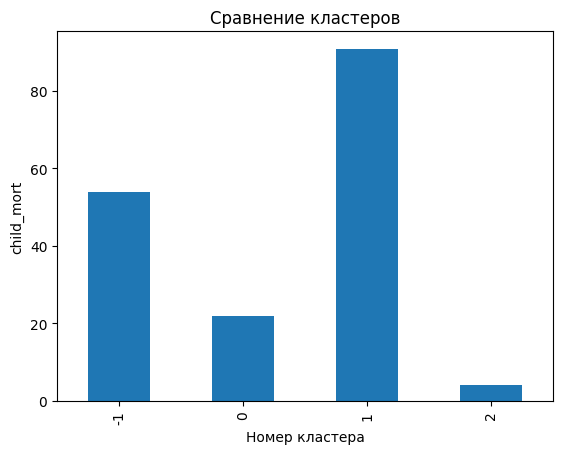

In [108]:
viz('child_mort')

<div class="alert-success"> 
<b> </b>
Кластер 1 лидер по детской смертности, 2 - наоборот
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак health</b>
</div>

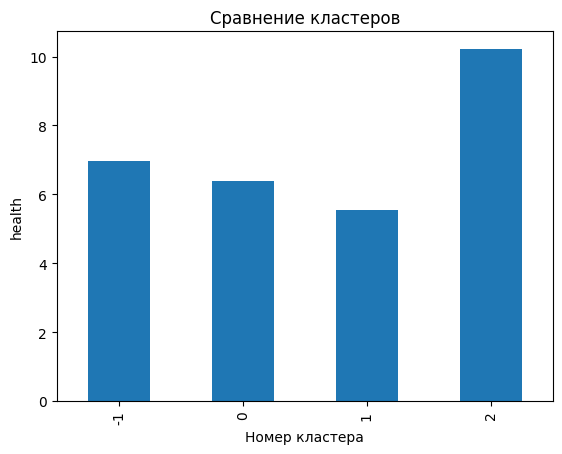

In [109]:
viz('health')

<div class="alert-success"> 
<b> </b>
Кластер 1 имеет наименьшие затраты на здравоохранение, кластер 2 раскошелился на данное удовольствие
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак income</b>
</div>

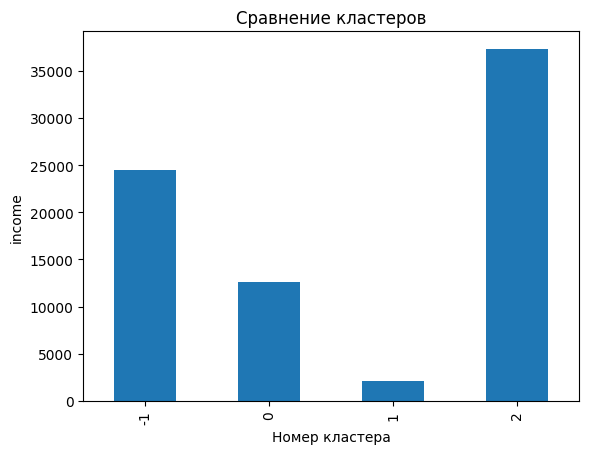

In [110]:
viz('income')

<div class="alert-success"> 
<b> </b>
Кластер 1 имеет наименьший чистый доход на человека, 2 - наибольший
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак inflation</b>
</div>

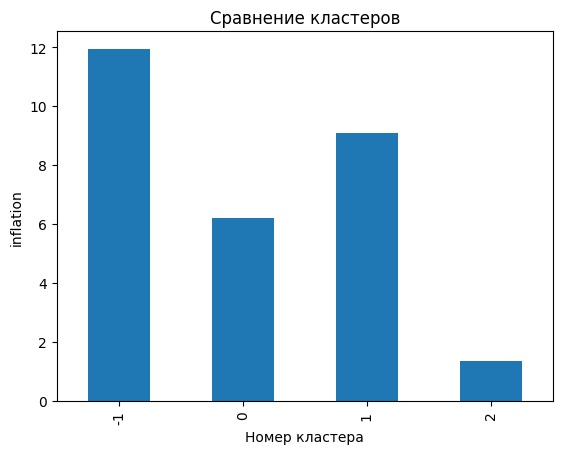

In [111]:
viz('inflation')

<div class="alert-success"> 
<b> </b>
Игнорируя кластер с шумом, кластер 1 имеет наивысшую инфляцию, 2 наименьшую
</div>

<div style="background-color: #fff3cd; border: 1px solid #ffeeba; padding: 10px; border-radius: 5px;">
<b>Признак gdpp</b>
</div>

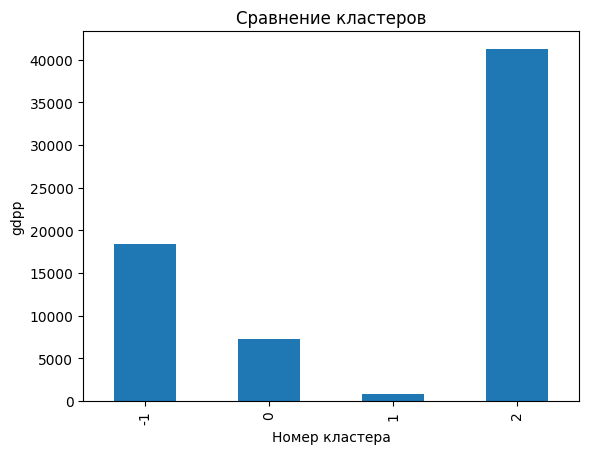

In [112]:
viz('gdpp')

<div class="alert-success"> 
<b> </b>
Кластер 2 - лидер по ВВП, кластер 1 наоборот - аутсайдер
</div>

In [113]:
sort_clusters = cluster_group.sort_values(by=['child_mort', 'income', 'gdpp', 'health', 'inflation'], ascending=[False, True, True, True, False])
print(sort_clusters[['child_mort', 'income', 'gdpp', 'health', 'inflation']].round(2))

                child_mort    income      gdpp  health  inflation
cluster_dbscan                                                   
 1                   90.83   2158.48    874.76    5.55       9.07
-1                   54.03  24489.69  18405.31    6.97      11.93
 0                   21.85  12602.96   7222.02    6.38       6.20
 2                    4.12  37312.50  41237.50   10.22       1.37


<div class="alert-success"> 
<b> </b>
Ну понятненько - кластер 1 - именно там нужно искать страны которым нужна помощь, также определим ТОП 6 стран КОМУ ТРЕБУЕТСЯ ПОМОЩЬ)
</div>

In [114]:
cluster_1 = data[data['cluster_dbscan'] == 1]

In [115]:
cluster_1_sort = cluster_1.sort_values(by=['child_mort', 'income', 'gdpp', 'health', 'inflation'], ascending=[False, True, True, True, False])

In [116]:
top_6 = cluster_1_sort[['country', 'child_mort', 'income', 'gdpp', 'health', 'inflation']].head(6)
print(top_6)

          country  child_mort  income  gdpp  health  inflation
97           Mali       137.0    1870   708    4.98      4.370
25   Burkina Faso       116.0    1430   575    6.74      6.810
64  Guinea-Bissau       114.0    1390   547    8.50      2.970
17          Benin       111.0    1820   758    4.10      0.885
40  Cote d'Ivoire       111.0    2690  1220    5.30      5.390
63         Guinea       109.0    1190   648    4.93     16.100


<div class="alert-success"> 
<b> </b>
Список стран поменялся, теперь СТРАНАМИ КОТОРУЮ В ПЕРВУЮ ОЧЕРЕДЬ НУЖНО ОКАЗЫВАТЬ ПОМОЩЬ СТАЛИ --->

1)Mali
2)Burkina Faso
3)Guinea-Bissau
4)Benin
5)Cote d'Ivoire
6)Guinea
</div>

In [117]:
print('ЭТАЛОННЫЕ СТРАНЫ ИЗ КЛАСТЕРОВ DBSCAN:')
for k in data['cluster_dbscan'].unique():
    if k == -1:
        continue
    cluster = X_normalized[data['cluster_dbscan'] == k]
    center = cluster.mean(axis=0).reshape(1, -1)
    dist = pairwise_distances(cluster, center).flatten()
    country = data.loc[data['cluster_dbscan'] == k].iloc[dist.argmin()]['country']
    print(f'Кластер {k}: эталонная страна — {country}')

ЭТАЛОННЫЕ СТРАНЫ ИЗ КЛАСТЕРОВ DBSCAN:
Кластер 1: эталонная страна — Malawi
Кластер 0: эталонная страна — Tunisia
Кластер 2: эталонная страна — United Kingdom


In [118]:
data[data['country'] == 'Malawi']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid,clusters_agg,distance_to_centroid_agg,cluster_dbscan
94,Malawi,90.5,22.8,6.59,34.9,1030,12.1,5.31,459,4,0.462974,0,0.513311,1


In [119]:
data[data['country'] == 'Tunisia']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid,clusters_agg,distance_to_centroid_agg,cluster_dbscan
152,Tunisia,17.4,50.5,6.21,55.3,10400,3.82,2.14,4140,5,0.53376,2,0.64511,0


In [120]:
data[data['country'] == 'United Kingdom']

,country,child_mort,exports,health,imports,income,inflation,total_fer,gdpp,clusters_kmeans,distance_to_centroid,clusters_agg,distance_to_centroid_agg,cluster_dbscan
158,United Kingdom,5.2,28.2,9.64,30.8,36200,1.57,1.92,38900,1,0.95823,1,1.056668,2


<div class="alert-success"> 
<b> </b>
Итак, давайте проанализируем каждый кластер с его эталонной страной)
</div>

<div class="alert-success"> 
<b> </b>
Кластер 0 - Средние по экономике и медицине страны, НЕ НУЖДАЮТСЯ В ПОМОЩИ. У них средние показатели по всем признакам.

- Эталонная страна - Тунис, все у ней хорошо, низкая детская смертность, средний импорт и экспорт и тд. Тунис - он классифицируется как развивающаяся страна с умеренным уровнем благосостояния по сравнению с другими африканскими странами.

Кластер 1 - страны в данном кластере являются бедными и НУЖДАЮТСЯ В ПОМОЩИ, у них наивысшая детская смертность и  высокая инфляция, зато самый низкий ВВП и уровень затрат на здравоохранение.

- Эталонная страна - МАЛАВИ - является одной из самых бедных стран мира и одной из самых бедных в Африке. Экономика страны сильно зависит от сельского хозяйства, в котором занята большая часть населения, а ключевым экспортным товаром является табак. Высокий уровень бедности в Малави обусловлен такими факторами, как низкий ВВП на душу населения, зависимость от аграрного сектора, подверженного влиянию климатических изменений, ограниченная инфраструктура и высокий темп роста населения.

Кластер 2 - самые благополучные богатые страны, с самой лучше медициной и экономикой. Лидеры по всем экономическим показателям и с самой низкой детсой смертностью.

- Эталонная страна - Великобритания — богатая страна с большой экономикой. Самый высокий ВВП из всех стран, самая низкая детская смертность - 5.2 - НЕ НУЖДАЮТСЯ В ПОМОЩИ, скорее всего они сами будут ее оказывать)

Кластер -1 - 'шумы' 
</div>

### ВЫВОД

<div class="alert-success"> 
<b> </b>
В данной работе были рассмотрены три алгоритма кластеризации, для каждого из них подобраны оптимальные значения параметров, что позволило кластеризовать данные а также выявить из них НУЖДАЮЩИЕСЯ СТРАНЫ, КОТОРЫМ НУЖНО ОКАЗАТЬ ПОДДЕРЖКУ В ПЕРВУЮ ОЧЕРЕДЬ. ВОТ ПОЛНЫЙ ИХ СПИСОК:
    
- 1)Haiti
- 2)Sierra Leone
- 3)Chad
- 4)Central African Republic
- 5)Mali
- 6)Nigeria
- 7)Mali
- 8)Burkina Faso
- 9)Guinea-Bissau
- 10)Benin
- 11)Cote d'Ivoire
- 12)Guinea

И правда, если мы загуглим эти страны, то увидим, что все эти страны — одни из беднейших и наименее развитых в мире. Их объединяет крайне низкий уровень жизни, высокая безработица, слабая экономика, зависимость от сельского хозяйства и сырья, а также огромная доля населения, живущая за чертой бедности. Социальная инфраструктура практически не развита: плохие дороги, слабая система образования, ограниченный доступ к чистой воде, электричеству и базовым услугам.

Медицинская ситуация также тяжёлая — нехватка врачей, лекарств и оборудования, низкий уровень вакцинации, высокая материнская и детская смертность, частые вспышки инфекций (малярия, холера, лихорадка, Эбола и т. д.). Средняя продолжительность жизни во многих из этих стран не превышает 55–60 лет.

В целом — это государства с крайне уязвленными социально-экономическими системами, хронической бедностью и слабыми здравоохранительными возможностями, где выживание населения часто зависит от гуманитарной помощи и международных организаций.

Именно поэтому важно их поддержать во всех сферах, дать денег, повышать уровень образования и медицины и т.д.
</div>

Работа выполнена Гареевой Д.Р (507540), j4150